Accuracy : 0.4166666666666667
Precision: 1.0
Recall   : 0.3333333333333333
F1 Score : 0.5
Classification Report:
               precision    recall  f1-score   support

    Negative       0.18      1.00      0.30         3
    Positive       1.00      0.33      0.50        21

    accuracy                           0.42        24
   macro avg       0.59      0.67      0.40        24
weighted avg       0.90      0.42      0.48        24

Confusion Matrix:
 [[ 3  0]
 [14  7]]


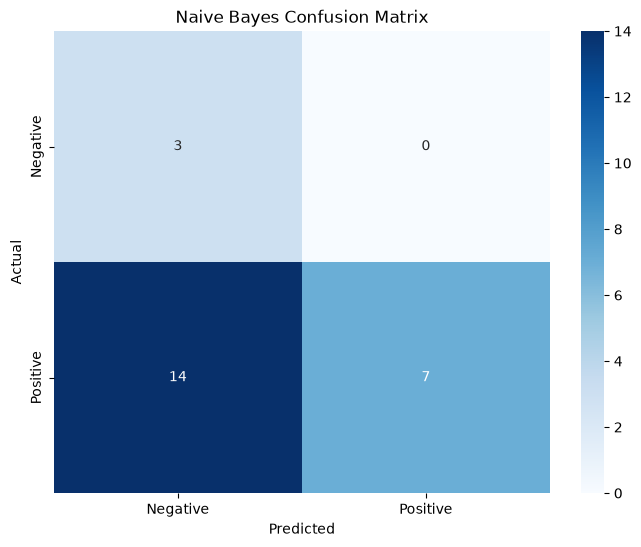

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,precision_score, recall_score
df=pd.read_csv("coronavirus_susceptibility.csv")
df=df.drop(["Patient_ID"],axis=1)

df["Cough"]=df["Cough"].fillna(df["Cough"].mode()[0])
df["Fatigue"]=df["Fatigue"].fillna(df["Fatigue"].mode()[0])
df["Fever"]=df["Fever"].fillna(df["Fever"].mode()[0])
df["Sore_Throat"]=df["Sore_Throat"].fillna(df["Sore_Throat"].mode()[0])
df["Diabetes"]=df["Diabetes"].fillna(df["Diabetes"].mode()[0])
df["Hypertension"]=df["Hypertension"].fillna(df["Hypertension"].mode()[0])
df["Exposure_History"]=df["Exposure_History"].fillna(df["Exposure_History"].mode()[0])
df["Vaccinated"]=df["Vaccinated"].fillna(df["Vaccinated"].mode()[0])
df["Body_Temperature_F"]=df["Body_Temperature_F"].fillna(df["Body_Temperature_F"].mean())
df["Oxygen_Level"]=df["Oxygen_Level"].fillna(df["Oxygen_Level"].mean())
df["Age"]=df["Age"].fillna(df["Age"].mean())
df=pd.get_dummies(df,columns=["Sex","Fever","Cough","Fatigue","Sore_Throat","Diabetes","Hypertension","Breathing_Difficulty","Exposure_History","Vaccinated"],drop_first=True)
df["Corona_Positive"]=df["Corona_Positive"].map({"Yes":1,"No":0})
x=df.drop(["Corona_Positive"],axis=1)
y=df["Corona_Positive"]
model=GaussianNB()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model.fit(x,y)
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("Classification Report:\n", classification_report(y_test, y_pred,target_names=["Negative", "Positive"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


